# Grayscale Image Filtering Basics
__Author__: Masa Prodanovic

__Last update__: Aug 2025

__References:__
1) Rafael Gonzales and Richard W. Woods, Digital Image Processing, 2nd edition, Prentice Hall 2001.

2) All Python Skimage filters: https://scikit-image.org/docs/dev/api/skimage.filters.html

3) Wang, Ying Da, Armstrong, Ryan, Mostaghimi, Peyman. "A Diverse Super Resolution Dataset of Digital Rocks (DeepRock-SR): Sandstone, Carbonate, and Coal." Digital Porous Media Portal (formerly Digital Rocks Portal),  https://www.doi.org/10.17612/s3m9-e024 

4) Bultreys, Tom. "Estaillades Carbonate #2.", Digital Porous Media Portal (formerly Digital Rocks Portal), https://www.doi.org/10.17612/P7C09J 

# Objective

We will load a few different porous media images, and introduce common gray scale image filtering techniques. 

__Filtering__ is manipulation and __always implies data/information loss__. This is done with an objective in mind, such losing noise to improve contrast between different phases in the image, or recognition of different objects.

Images differ in data types and range of values, and the first step should always be understanding histogram of the image values and basic statistics.

In [ ]:
# Standard library imports
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

try:
    import dpm_tools
    assert dpm_tools.__version__ >= "0.0.4"
except ModuleNotFoundError:
    !pip install --user -r ./requirements.txt
except AssertionError:
    !pip install --upgrade dpm_tools --user

# Anisotropic diffusion filter is found in MedPy 
# https://pypi.org/project/MedPy/
try:
    import medpy
except ModuleNotFoundError:
    !pip install --upgrade pip setuptools wheel
    !pip install medpy

# Third-party imports
import skimage as si
import skimage.filters as sf
import skimage.morphology as sm
import skimage.transform as st
from skimage import io, img_as_float, img_as_ubyte, img_as_int, exposure
from skimage.metrics import peak_signal_noise_ratio, mean_squared_error
from medpy.filter.smoothing import anisotropic_diffusion

import dpm_tools
from dpm_tools.io import download_file
from dpm_tools.metrics import histogram_statistics as hist_stats

from scipy import ndimage  # used for convolve function

from pathlib import Path
import os
import sys
sys.path.append("..")
from utils.dataloader import load_sample
download_path = Path("/home/jovyan/work/ls6")

In [3]:
# This sets precision standard for printing real numbers for this entire notebook.
np.set_printoptions(precision=2)

# This should enforce the same, "short" formatting for printing floating points in numpy.
# hist_stats function from dpm_tools does not obey.
#float_formatter = "{:.2f}".format
#np.set_printoptions(formatter={'float_kind':float_formatter})

# Examples
## Download and/or read in a 2D sandstone image from Digital Rocks Portal and  plot/compare image stats

I found a nice set of 2D sandstone slices at two different resolutions in Dataset 211. These are X-ray microtomography images.
Ying Da Wang, Peyman Mostaghimi, Ryan Armstrong. A Super Resolution Dataset of Digital Rocks (DRSRD1): Sandstone and Carbonate. Digital Rocks Portal (April 2025). https://www.doi.org/10.17612/P7D38H

In [4]:
# higher resolution image
img_hr = load_sample("sandstone_2d_high_res", cache_dir=download_path)

# this is a lower resolution image
img_lr = load_sample("sandstone_2d_low_res", cache_dir=download_path)

Loading cached sample 'sandstone_2d_high_res' from /home/gomathecat/sandstone_2d_high_res.tif


__These images are the same sample imaged at higher and lower resolutions.__
__We read images, and display the entire images as well as smaller subsets where we can appreciate the differences.__

__Color shown is the default colormap of matplotlib. This is NOT true color, x-ray images have single values, but I use it instead of
gray as differences on screen tend to be better visible than in gray__

Text(0.5, 1.0, 'lower res')

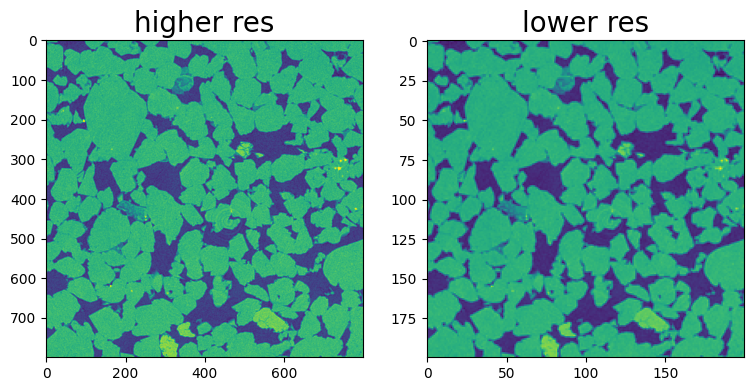

In [5]:
img_hr = img_hr[:,:,0] #use only one channel of the three channels available

img_lr = img_lr[:,:,0] #use only one channel of the three channels available

f = plt.figure(figsize=(9, 18))
f.add_subplot(121)
plt.imshow(img_hr) # if the image has three channels, default - and fake - color will appear when using imshow. Color scheme can easily be changed.
plt.title('higher res',fontsize=20)

f.add_subplot(122)
plt.imshow(img_lr) # if the image has three channels, default - and fake - color will appear when using imshow
plt.title('lower res',fontsize=20)

Text(0.5, 1.0, 'zoom in - lower res')

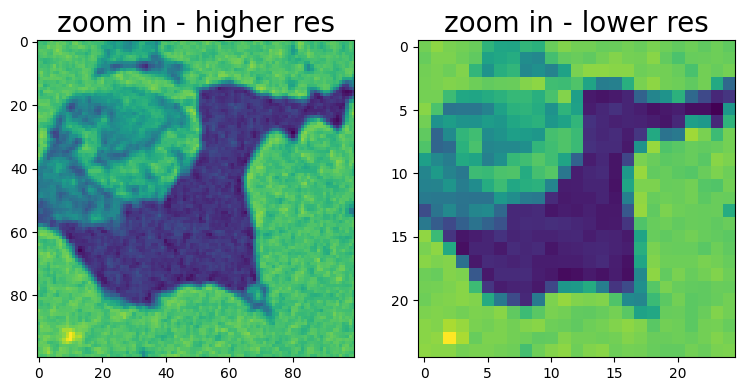

In [6]:
# Zoom into a subset
# location and length of an image subset in x, y directions
locx = 80
lenx = 100
locy = 320
leny = 100

f = plt.figure(figsize=(9, 18))
f.add_subplot(121)
plt.imshow(img_hr[locx:(locx+lenx),locy:(locy+leny)]) # add cmap='gray' to imshow function to change colormap to gray.
plt.title('zoom in - higher res',fontsize=20)

f.add_subplot(122)
# note that // is floor division (so we get integers as a result)
plt.imshow(img_lr[locx//4:(locx+lenx)//4,locy//4:(locy+leny)//4]) 
plt.title('zoom in - lower res',fontsize=20)

__Now look into the basic statistics of the images. Do you think we will observe a difference in the image histograms and what will the difference be?__

-----------------------------------
Image statistics:
	Shape: (800, 800)
	Data type: uint8
	Min: 20, Max:               255, Mean: 148.16875625

-----------------------------------
Image statistics:
	Shape: (200, 200)
	Data type: uint8
	Min: 35, Max:               255, Mean: 148.17455



[{'shape': (800, 800),
  'dtype': dtype('uint8'),
  'min': 20,
  'max': 255,
  'mean': 148.16875625,
  'median': 172.0,
  'variance': 2288.5133432030857,
  'skewness': 0.0,
  'kurtosis': -1.200036621652552},
 {'shape': (200, 200),
  'dtype': dtype('uint8'),
  'min': 35,
  'max': 255,
  'mean': 148.17455,
  'median': 173.0,
  'variance': 2078.3071822975,
  'skewness': 0.0,
  'kurtosis': -1.2000366216525522}]

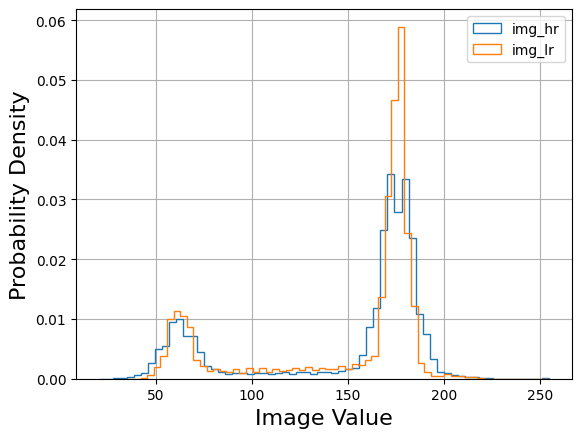

In [7]:
# I would typically use 256 bins here, however, it seems that some of the values in 0..255 
# range do not exist in the images, so that creates an ugly histogram.
hist_stats(img_hr, img_lr, plot_histogram=True, nbins=64, legend_elem=["img_hr", "img_lr"])

__Lower resolution image has more distinct phases showing in histogram (narrower and higher peaks): you can see the reason in the above visualization: some of the "noise" within grains is effectively smoothed out, for all grains and especially the ones that appear to have some partial dissolution and/or where there is clay.__

## Geometric transformations
Rotation is something that you would commonly do for engineering reasons, 
and it is not filtering per se. This is one example using skimage library. Check skimage.transform for more.

__Note that by conventions, skimage functions convert all images to [0,1] float64 range. That is necessary for operations that often have non-integer result. This may cause error in calculation as well as increase the memory footprint of your calculation.__

Using skimage.transform.rotate() function:
https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.rotate

-----------------------------------
Image statistics:
	Shape: (50, 50)
	Data type: float64
	Min: 0.13725490196078433, Max:               0.803921568627451, Mean: 0.5936203921568628

-----------------------------------
Image statistics:
	Shape: (50, 50)
	Data type: float64
	Min: 0.0, Max:               0.7755461284234944, Mean: 0.4902209788391394

-----------------------------------
Image statistics:
	Shape: (50, 50)
	Data type: float64
	Min: 0.0, Max:               0.06731141059192836, Mean: 0.008365992551653928



Text(0.5, 1.0, 'Difference')

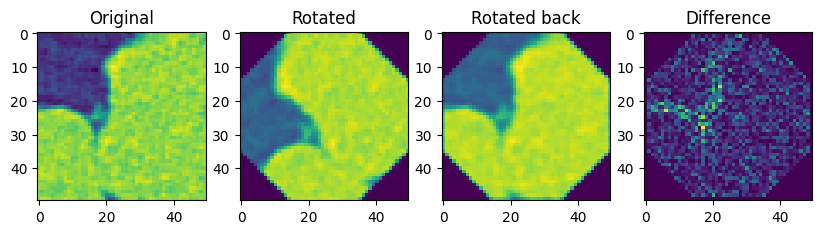

In [8]:
# location and length of an image subset in x, y directions
locx = 500
lenx = 50
locy = 440
leny = 50

f.add_subplot(223)
img_sub = img_as_float(np.copy(img_hr[locx:(locx+lenx),locy:(locy+leny)])) # floating point values
angle = 45; # counter-clockwise angle of rotation
img_rot = st.rotate(img_sub,angle)
img_back = st.rotate(img_rot,-angle)
#img_diff = np.ubyte(np.round(img_sub - img_back))
img_diff = np.abs(img_sub-img_back)

##Remove boundary regions from the difference image to visualize changes in data properties from rotation operations
img_zero = np.equal(img_rot,0)
img_zero = ndimage.binary_dilation(img_zero, structure=ndimage.generate_binary_structure(2, 2)).astype(img_zero.dtype)

img_zero[:,[0,lenx-1]] = 1
img_zero[[0,leny-1],:] = 1
img_diff = img_diff*(1-img_zero)
##

hist_stats(img_sub)
hist_stats(img_back)
hist_stats(img_diff)

f = plt.figure(figsize=(10, 24))
f.add_subplot(141)
plt.imshow(img_sub)
plt.title('Original')

f.add_subplot(142)
plt.imshow(img_rot)
plt.title('Rotated')

f.add_subplot(143)
plt.imshow(img_back)
plt.title('Rotated back')

f.add_subplot(144)
plt.imshow(img_diff)
plt.title('Difference')

## Gaussian smoothing

The simplest filter and very common filter that removes "speckled" noise, but it also smooths out (and possibly even removes) edges or thin features: __in porous media use very cautiously as you might negatively impact the contrast__


[[0. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]
Smooth, sigma = 0.4

 [[0.   0.04 0.  ]
 [0.04 0.84 0.04]
 [0.   0.04 0.  ]]
Smooth, sigma = 1

 [[0.06 0.1  0.06]
 [0.1  0.16 0.1 ]
 [0.06 0.1  0.06]]
Reflected boundaries, sigma = 1

 [[0.09 0.12 0.09]
 [0.12 0.17 0.12]
 [0.09 0.12 0.09]]


Text(0.5, 1.0, 'Gauss, sigma = 1, reflect bdaries')

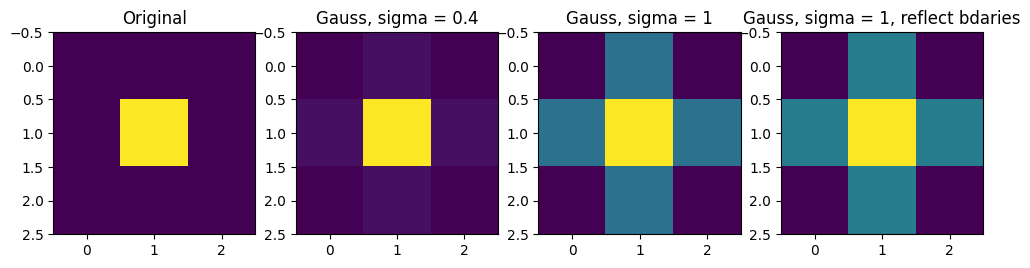

In [9]:
# Create a simple, 3 by 3 image with only one point feature which is one voxel. 
a = np.zeros((3, 3))
a[1, 1] = 1
print(a)
a_smooth = sf.gaussian(a, sigma=0.4)

print('Smooth, sigma = 0.4\n\n', a_smooth)

a_smoother = sf.gaussian(a, sigma=1) 
print('Smooth, sigma = 1\n\n', a_smoother)

# Several modes are possible for handling boundaries
a_reflect = sf.gaussian(a, sigma=1, mode='reflect')
print('Reflected boundaries, sigma = 1\n\n', a_reflect)

f = plt.figure(figsize=(12, 24))

f.add_subplot(141)

plt.imshow(a)
plt.title('Original')

f.add_subplot(142)
plt.imshow(a_smooth)
plt.title('Gauss, sigma = 0.4')

f.add_subplot(143)
plt.imshow(a_smoother)
plt.title('Gauss, sigma = 1')

f.add_subplot(144)
plt.imshow(a_reflect)
plt.title('Gauss, sigma = 1, reflect b''daries')

#>>> # For RGB images, each is filtered separately
#>>> from skimage.data import astronaut
#>>> image = astronaut()
#>>> filtered_img = gaussian(image, sigma=1, multichannel=True)

### Exercise 
Create a 5 x 5 image with a straight line feature through its middle. Then apply the above three filters to observe what happens during smoothing.

__Let's now "smooth" one of the sandstone images and plot differences__

On the difference plot, most values are very small but notably the largest changes (absolute differences) are near the boundary of two phases. __That reduces contrast between two materials, and is very bad effect.__

We will also report PSNR and MSE measures between the image and its filtered version.


Gaussian, sigma=1.0, psnr= 31.905106910292687    mse= 0.0006448954442785687


Text(0.5, 1.0, 'Abs. difference (for sigma=1)')

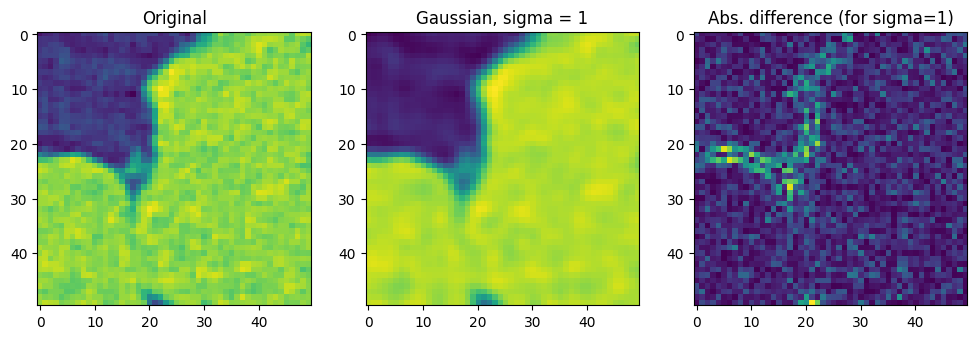

In [10]:
img_sub = img_as_float(np.copy(img_hr[locx:(locx+lenx),locy:(locy+leny)])) # floating point values

f = plt.figure(figsize=(12, 18))

f.add_subplot(131)
plt.imshow(img_sub)
plt.title('Original')

img_smoother = sf.gaussian(img_sub,1)
f.add_subplot(132)
plt.imshow(img_smoother)
plt.title('Gaussian, sigma = 1')

psnr = peak_signal_noise_ratio(img_sub, img_smoother)
mse = mean_squared_error(img_sub,img_smoother)
print('Gaussian, sigma=1.0, psnr=',psnr, '   mse=',mse)

f.add_subplot(133)
img_diff = np.abs(img_smoother-img_sub)
plt.imshow(img_diff)
plt.title('Abs. difference (for sigma=1)')

__Use Gaussian smoothing on the entire image and visualize the impact on histogram.__

-----------------------------------
Image statistics:
	Shape: (800, 800)
	Data type: float64
	Min: 0.0784313725490196, Max:               1.0, Mean: 0.5810539460784314

-----------------------------------
Image statistics:
	Shape: (800, 800)
	Data type: float64
	Min: 0.13687703313565477, Max:               0.9998484846768962, Mean: 0.581054107534407



[{'shape': (800, 800),
  'dtype': dtype('float64'),
  'min': 0.0784313725490196,
  'max': 1.0,
  'mean': 0.5810539460784314,
  'median': 0.6745098039215687,
  'variance': 0.035194361294934036,
  'skewness': -5.528155746483105e-16,
  'kurtosis': -1.2000366216525513},
 {'shape': (800, 800),
  'dtype': dtype('float64'),
  'min': 0.13687703313565477,
  'max': 0.9998484846768962,
  'mean': 0.581054107534407,
  'median': 0.6764128778554637,
  'variance': 0.03198742037540669,
  'skewness': -1.122077305771406e-16,
  'kurtosis': -1.200036621652552}]

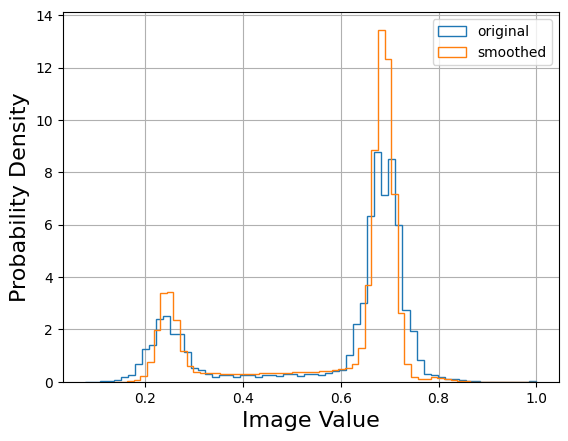

In [11]:
img_hr_float = si.img_as_float(img_hr)
img_hr_smooth = sf.gaussian(img_hr_float,1.0)
hist_stats(img_hr_float,img_hr_smooth,plot_histogram=True,nbins=64,legend_elem=["original", "smoothed"])

## Median filtering

We can replace a voxel with the median of the values in its __neighborhood__ or so-called __structuring element__.  For this we first need to define what the neighborhood is, and depending on its size, the effect of filtering is smaller or bigger. We will stick to squares/cubes or disks/balls
but the neighborhoods could be anything. You can read more here: https://scikit-image.org/docs/dev/auto_examples/numpy_operations/plot_structuring_elements.html#sphx-glr-auto-examples-numpy-operations-plot-structuring-elements-py

__Median filter__ is likely one of the best filters to use in porous media images, especially CT images. It sorts the values in a given neighborhood, and finds the median. If I have a 3 by 3 neighborhood, and some noise that is less than 3*3/2 in area, than that noise will be replaced. Statistically speaking, the median is 50th percentile of a ranked set of numbers. I could also choose maximum (100th percentile), minimum (0th percentile) and anything in between.

CT noise is complex (not randomized, but nonlinear), and median filtering with a relatively small
neighbohood of 3 to 5 voxels wide will remove outliers, and will not have a large effect on the boundaries (edges) between phases that Gaussian filter might blur.

Further, by design it does _not_ introduce new values (i.e. numbers that previously did not exist) into the image. This is good since I could operate on integers, and the resulting image is still integer.

__Structural elements (neighborhoods): 2D and 3D examples__

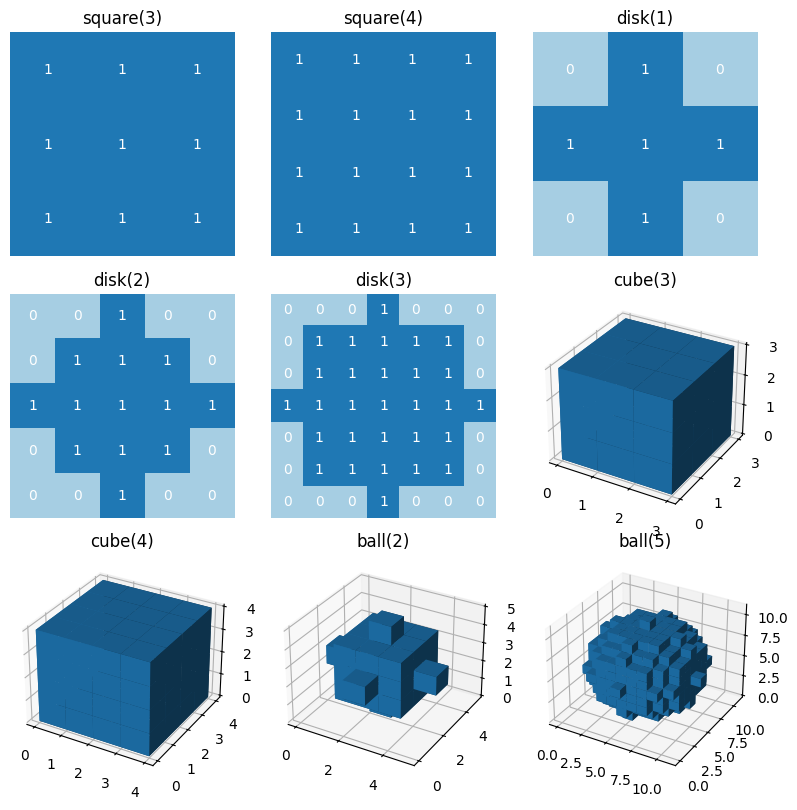

In [12]:
# let's create different neighborhooods in different shapes
# Example is from skimage documentation.

struc_2d = {
    "square(3)": sm.square(3),
    "square(4)": sm.square(4),
    "disk(1)": sm.disk(1),
    "disk(2)": sm.disk(2),
    "disk(3)": sm.disk(3)
}

struc_3d = {
    "cube(3)": sm.cube(3),
    "cube(4)": sm.cube(4),
    "ball(2)": sm.ball(2),
    "ball(5)": sm.ball(5)
}

# Visualize the elements.
fig = plt.figure(figsize=(8, 8))

idx = 1
for title, struc in struc_2d.items():
    ax = fig.add_subplot(3, 3, idx)
    ax.imshow(struc, cmap="Paired", vmin=0, vmax=12)
    for i in range(struc.shape[0]):
        for j in range(struc.shape[1]):
            ax.text(j, i, struc[i, j], ha="center", va="center", color="w")
    ax.set_axis_off()
    ax.set_title(title)
    idx += 1

for title, struc in struc_3d.items():
    ax = fig.add_subplot(3, 3, idx, projection='3d')
    ax.voxels(struc)
    ax.set_title(title)
    idx += 1

fig.tight_layout()
plt.show()


Text(0.5, 1.0, 'Abs. difference')

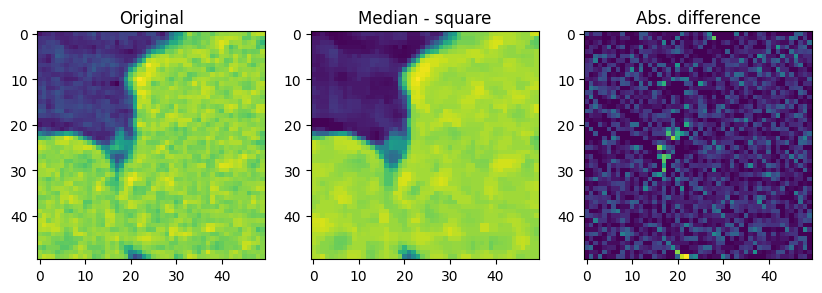

In [13]:
f = plt.figure(figsize=(10, 24))

f.add_subplot(131)

img_sub = img_as_float(np.copy(img_hr[locx:(locx+lenx),locy:(locy+leny)])) # floating point values
#img_sub = np.copy(img_hr[locx:(locx+lenx),locy:(locy+leny)])

plt.imshow(img_sub)
plt.title('Original')

f.add_subplot(132)
img_med = sf.median(img_sub,sm.square(3))
plt.imshow(img_med)
plt.title('Median - square')

f.add_subplot(133)
img_diff = np.abs(img_as_int(img_med)-img_as_int(img_sub)) # convert to int for math to work if negative numbers show up.
plt.imshow(img_diff)
plt.title('Abs. difference')

# hist_stats(img_diff,plot_histogram=True,nbins=32,legend_elem=['Abs. differences'])

## Mean filtering (averaging)
We could also replace every pixel with the mean (average) of the values in the defined neighborhood. It should be relatively obvious how this would "smooth" out any extreme differences in the image.
https://scikit-image.org/docs/dev/api/skimage.filters.rank.html#skimage.filters.rank.mean

__If you compare the difference image to the median filter difference image above, you will see that 
median filter does not smooth the boundary of the material as much. That is good for contrast.__


Text(0.5, 1.0, 'Abs. difference')

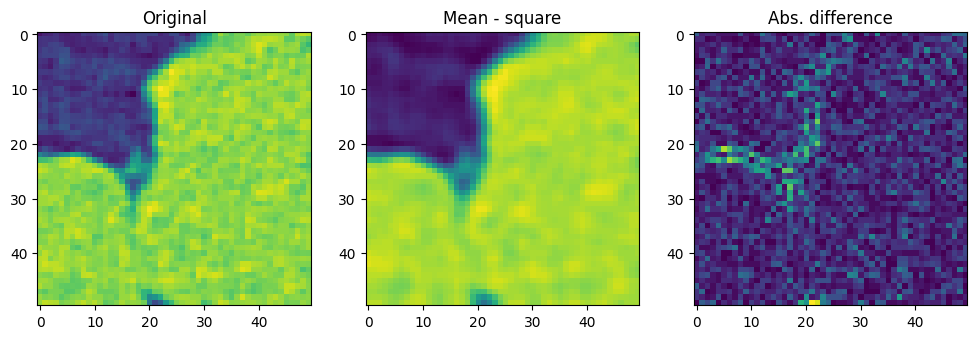

In [14]:
f = plt.figure(figsize=(12, 18))

f.add_subplot(131)

img_sub = np.copy(img_hr[locx:(locx+lenx),locy:(locy+leny)]) # integers, NOT floating point values

plt.imshow(img_sub)
plt.title('Original')

f.add_subplot(132)
img_mean = sf.rank.mean(img_sub,sm.square(3)) # this returns integers too
plt.imshow(img_mean)
plt.title('Mean - square')

f.add_subplot(133)
img_diff = np.abs(si.img_as_float(img_mean)-si.img_as_float(img_sub))
plt.imshow(img_diff)
plt.title('Abs. difference')


## Anisotropic diffusion

We will use a carbonate example with microporosity where the filtering really matters.

### Carbonate example with microporosity: read image (2D) from Digital Porous Media Portal (formely Digital Rocks Portal)

This example has pore space, microporous space and solid phase. Microporosity is not well resolved, and in return the histogram does not show clear three peaks as the phases are not well separated.

[22:43:48] ERROR    <TiffTag.fromfile> raised TiffFileError('<tifffile.TiffTag 320 @8000226>       ]8;id=897613;file:///home/gomathecat/myvenvs/nocturn/lib64/python3.11/site-packages/tifffile/tifffile.py\tifffile.py]8;;\:]8;id=672311;file:///home/gomathecat/myvenvs/nocturn/lib64/python3.11/site-packages/tifffile/tifffile.py#8134\8134]8;;\
                    invalid value offset 0')                                                                       

-----------------------------------
Image statistics:
	Shape: (2000, 2000)
	Data type: uint16
	Min: 0, Max:               65535, Mean: 27121.9634945



[{'shape': (2000, 2000),
  'dtype': dtype('uint16'),
  'min': 0,
  'max': 65535,
  'mean': 27121.9634945,
  'median': 29281.0,
  'variance': 183817062.66129643,
  'skewness': 0.0,
  'kurtosis': -1.200036621652552}]

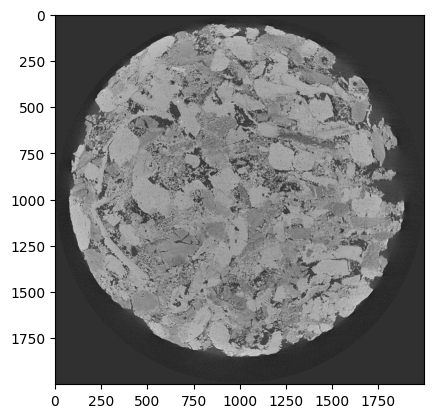

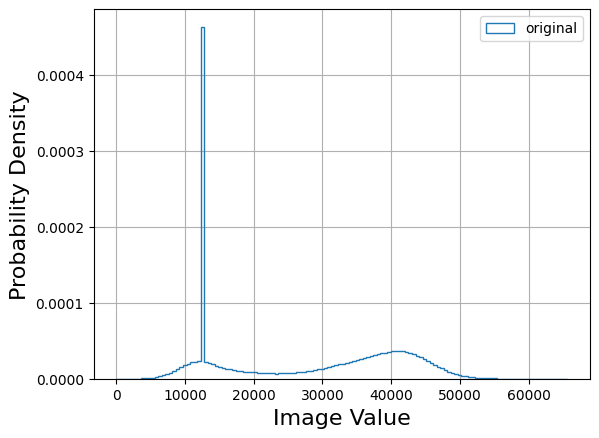

In [15]:
#download
# Project 58, Estaillades carbonate #2 has a nice if complex CT of a carbonate sample
img_carbonate = load_sample("estaillades", cache_dir=download_path)


plt.imshow(img_carbonate, cmap='gray')
hist_stats(img_carbonate,plot_histogram=True,nbins=128,legend_elem=['original'])

The ultimate goal is to see three peaks (or the emergence of the three peaks) in the histogram of the carbonate example without smoothing across the boundaries between region pairs. There is too much overlap between phase peaks, and I would not trust image thresholding in this type of a material.

We will try anisotropic diffusion from medPy
http://loli.github.io/medpy/generated/medpy.filter.smoothing.anisotropic_diffusion.html


(2000, 2000)
-----------------------------------
Image statistics:
	Shape: (300, 300)
	Data type: uint16
	Min: 5693, Max:               63714, Mean: 34106.38991111111

-----------------------------------
Image statistics:
	Shape: (300, 300)
	Data type: float32
	Min: 7474.10107421875, Max:               62731.19921875, Mean: 34106.38671875



[{'shape': (300, 300),
  'dtype': dtype('uint16'),
  'min': 5693,
  'max': 63714,
  'mean': 34106.38991111111,
  'median': 36859.0,
  'variance': 80087465.64254712,
  'skewness': 1.0391930368871406e-16,
  'kurtosis': -1.2000366216525522},
 {'shape': (300, 300),
  'dtype': dtype('float32'),
  'min': 7474.101,
  'max': 62731.2,
  'mean': 34106.387,
  'median': 36895.758,
  'variance': 77400104.0,
  'skewness': 3.8753308954455813e-07,
  'kurtosis': -1.2000364100939922}]

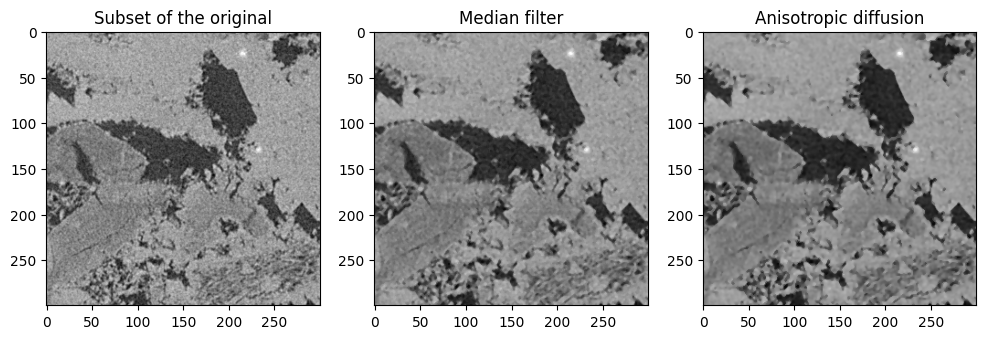

<Figure size 640x480 with 0 Axes>

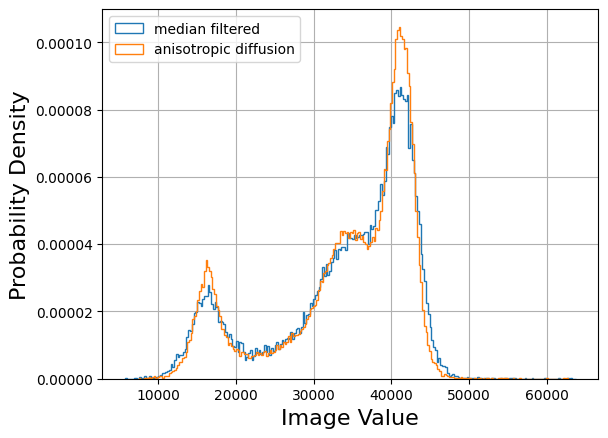

In [16]:
import medpy
from medpy.filter.smoothing import anisotropic_diffusion

# This is a large slice...take a subsample 
print(img_carbonate.shape)

#Subsample and convert to uint8
N=300
img_csub = img_carbonate[450:450+N,450:450+N]

f = plt.figure(figsize=(12,18))

f.add_subplot(131)
plt.imshow(img_csub,cmap='gray')
plt.title("Subset of the original")

f.add_subplot(132)
img_cmed = sf.median(img_csub,sm.square(3))
plt.imshow(img_cmed,cmap='gray')
plt.title('Median filter')

f.add_subplot(133)
# I have to use pretty large kappa as image values here are large (otherwise nothing happens)
# See histogram for comparison of before and after anisotropic diffusion. 
# I need three "peaks" to start forming, as there is pore space, solid phase and microporous phase.

# Also note: the algorithm below does NOT convert images to [-1,1] floats the way skimage does.
# It simply converts them to a floating point, equivalent value.
img_ani = anisotropic_diffusion(img_cmed,kappa=5000,niter=5,gamma=0.2,option=3)
plt.imshow(img_ani,cmap='gray')
plt.title('Anisotropic diffusion')

# image histogram is now stored in a separate Python file drp_util.py
plt.figure()
hist_stats(img_cmed,img_ani,plot_histogram=True,nbins=256,legend_elem=['median filtered','anisotropic diffusion'])

## Beyond basics: Spatial filtering and convolutions

With simple examples above we have intuitively introduced ideas of spatial filtering basics, that are intimately linked to the idea of convolutions and cross-correlations....this requires a bit of reading and/or viewing.

Reading: section 3.5 in R. Gonzales and R. W. Woods, Digital Image Processing, 2nd edition, Prentice Hall 2001.  (digital access possible through UT Library)

Videos:
Convolutions and cross-correlation by G. Jensen (Caltech, 15min):
https://www.youtube.com/watch?v=MQm6ZP1F6ms

The above video is the last part of the series on Fourier Transforms in imaging applications: https://www.youtube.com/watch?v=-EAQm8wgLbc

Visual intro to Fourier Transform (3blue1brown, 20min): https://www.youtube.com/watch?v=spUNpyF58BY

__Issues to resolve above:__
- Why is probability in histograms above > 1 in some cases?
- sf.rank.mean returns uint8 image. Why is that?



### Convolution with user-defined kernel

The function scipy.ndimage.convolve can convolve any ndarray with a predefined kernel.
https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.convolve.html#scipy.ndimage.convolve
    
We will use it to show Laplacian (second order differential operator) of an image. Both input and output are rather noisy.

Text(0.5, 1.0, 'Laplace isotropic')

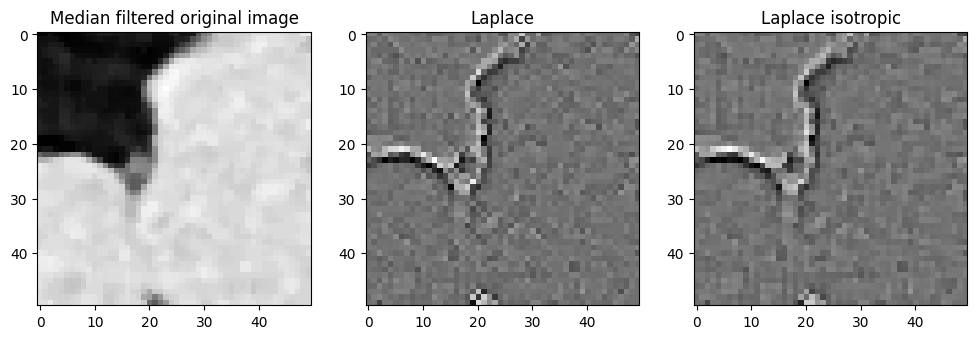

In [17]:
# We derived Laplacian kernel in class. 
k_l = np.array([[0,1,0],  [1,-4,1],  [0,1,0]])

#Isotropic version of the Laplacian kernel has diagonal elements as well
k_l_iso = np.array([[1,1,1], [1,-8,1], [1,1,1]])

img_laplace= ndimage.convolve(img_as_float(img_med), k_l, mode='reflect')
img_laplace_iso= ndimage.convolve(img_as_float(img_med), k_l_iso, mode='reflect')

f = plt.figure(figsize=(12, 18))

f.add_subplot(131)

plt.imshow(img_med,cmap='gray')
plt.title('Median filtered original image')

f.add_subplot(132)
plt.imshow(img_laplace,cmap='gray')
plt.title('Laplace')

f.add_subplot(133)
plt.imshow(img_laplace_iso,cmap='gray')
plt.title('Laplace isotropic')


-----------------------------------
Image statistics:
	Shape: (50, 50)
	Data type: float64
	Min: -0.6039215686274508, Max:               0.4784313725490198, Mean: -7.860379014346108e-17



Text(0.5, 1.0, 'Laplace isotropic and Laplace difference')

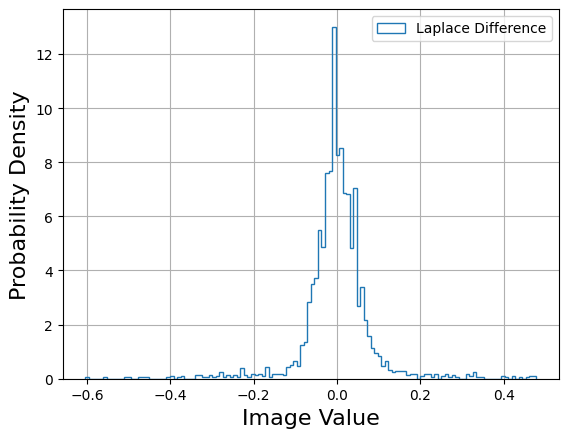

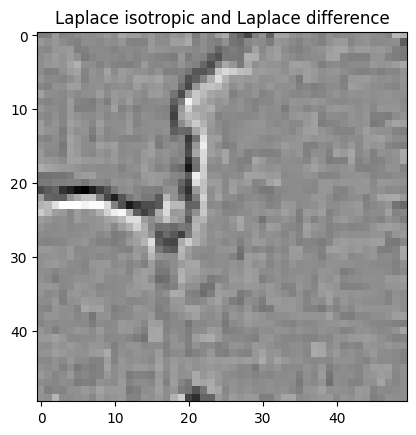

In [18]:
img_diff = img_laplace - img_laplace_iso
hist_stats(img_diff,plot_histogram=True,nbins=128, legend_elem=['Laplace Difference'])
plt.figure()
plt.imshow(img_diff,cmap='gray')
plt.title('Laplace isotropic and Laplace difference')

### Gradient (magnitude) and edge finding
__Sobel__ filter is a variant that computes computational-time-friendly version of 
the gradient magnitude. 

$$ \sqrt(\frac{\partial f}{\partial x}^2 + \frac{\partial f}{\partial y }^2)$$

It is used to identify edges in an image.

Text(0.5, 1.0, 'Sobel')

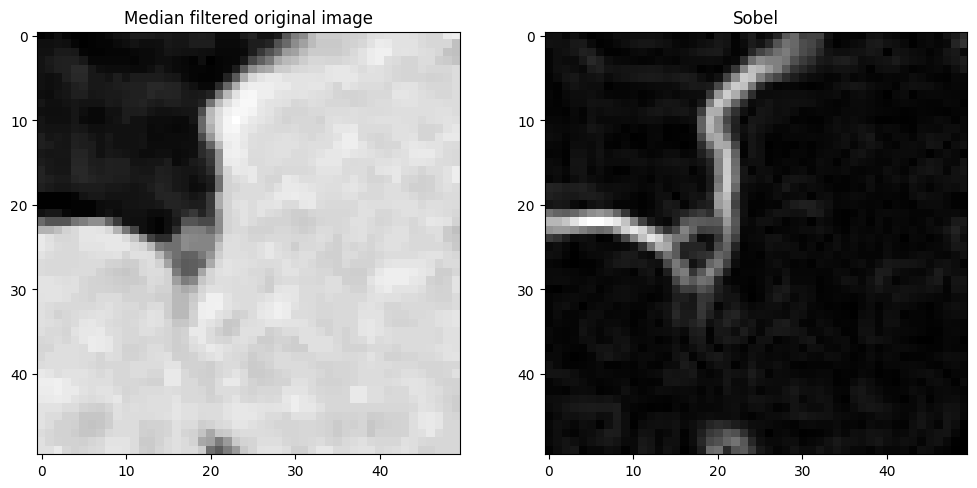

In [19]:
f = plt.figure(figsize=(12, 12))

f.add_subplot(121)

plt.imshow(img_med,cmap='gray')
plt.title('Median filtered original image')

f.add_subplot(122)
img_sobel = sf.sobel(img_med)
plt.imshow(img_sobel,cmap='gray')
plt.title('Sobel')

### Non-local means denoising

(not covered in class for now; project 125 images on DRP should be good examples for this, too)

Code adapted from https://scikit-image.org/docs/dev/auto_examples/filters/plot_nonlocal_means.html

This algorithm is implemented with three-channel images, and apparently will not work with only one channel (which how x-ray microtomoegraphy files are often recorded). That is easily overcome by copying that one channel into three to create grayscale RGB version of if, but could be problematic for large images as it uses three times the memory.

The example shows does the following:
- Use original image and add Gaussian noise to it (with known sigma). So this noisy image has both the original noise and added Gaussian noise.
- Then it estimates the standard deviation of the this noisy image (using an algorithm that estimates noise assuming it is Gaussian.
- Denoising (four different variations) works with a noisy image and does a pretty good job.

__PSNR stands for peak signal-to-noise ratio and it is calculated with the original image being a reference. 
It's a metric used to measure the quality of an image or video by comparing the power of the signal to the power of the noise: higher PSNR means higher quality image.__


Loading cached sample 'sandstone_2d_high_res' from /home/gomathecat/sandstone_2d_high_res.tif
(50, 50, 3)
estimated noise standard deviation = 0.07802689677986005
estimated noise from original = 0.013308664446678753
PSNR (noisy) = 21.95
PSNR (slow) = 30.42
PSNR (slow, using sigma) = 30.36
PSNR (fast) = 29.92
PSNR (fast, using sigma) = 30.10


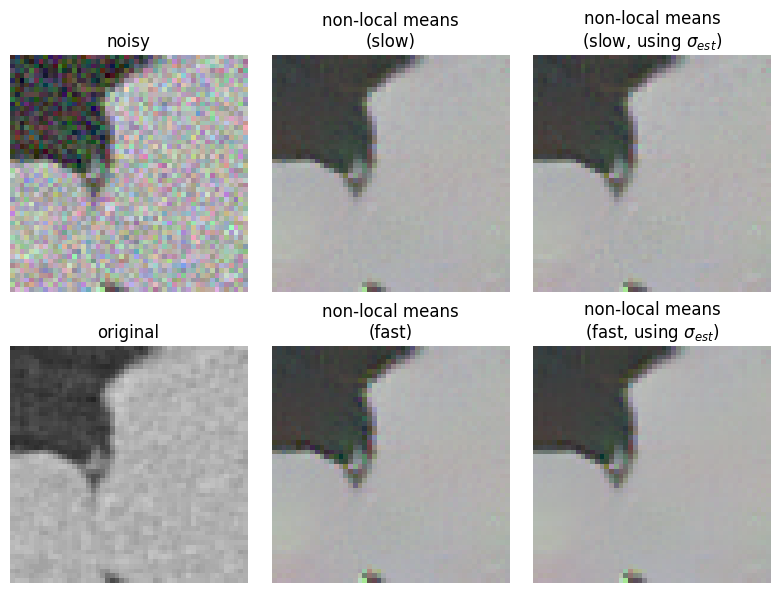

In [20]:
# Code base used is 
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_float
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.metrics import peak_signal_noise_ratio
from skimage.util import random_noise

# original example worked with an astronout image
#astro = img_as_float(data.astronaut())
#astro = astro[30:180, 150:300]

img_hr = load_sample("sandstone_2d_high_res", cache_dir=download_path)
img_sub = img_hr[locx:(locx+lenx),locy:(locy+leny),:] #keeping all three channels
astro = img_as_float(img_sub)

print(np.shape(astro))
astro.dtype

sigma = 0.08
noisy = random_noise(astro, var=sigma**2)

# estimate the noise standard deviation from the noisy image
sigma_est = np.mean(estimate_sigma(noisy, channel_axis=-1))
print(f'estimated noise standard deviation = {sigma_est}')

# estimate the noise standard deviation from the original - what do I get?
sigma_est_orig = np.mean(estimate_sigma(astro, channel_axis=-1))
print(f'estimated noise from original = {sigma_est_orig}')

patch_kw = dict(
    patch_size=5,  # 5x5 patches
    patch_distance=6,  # 13x13 search area
    channel_axis=-1,
)

# slow algorithm
denoise = denoise_nl_means(noisy, h=1.15 * sigma_est, fast_mode=False, **patch_kw)

# slow algorithm, sigma provided
denoise2 = denoise_nl_means(noisy, h=0.8 * sigma_est, sigma=sigma_est, fast_mode=False, **patch_kw)

# fast algorithm
denoise_fast = denoise_nl_means(noisy, h= 0.8*sigma_est, fast_mode=True, **patch_kw)

# fast algorithm, sigma provided
denoise2_fast = denoise_nl_means(noisy, h=0.6 * sigma_est, sigma=sigma_est, fast_mode=True, **patch_kw)

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(8, 6), sharex=True, sharey=True)

ax[0, 0].imshow(noisy)
ax[0, 0].axis('off')
ax[0, 0].set_title('noisy')
ax[0, 1].imshow(denoise)
ax[0, 1].axis('off')
ax[0, 1].set_title('non-local means\n(slow)')
ax[0, 2].imshow(denoise2)
ax[0, 2].axis('off')
ax[0, 2].set_title('non-local means\n(slow, using $\\sigma_{est}$)')
ax[1, 0].imshow(astro)
ax[1, 0].axis('off')
ax[1, 0].set_title('original')
ax[1, 1].imshow(denoise_fast)
ax[1, 1].axis('off')
ax[1, 1].set_title('non-local means\n(fast)')
ax[1, 2].imshow(denoise2_fast)
ax[1, 2].axis('off')
ax[1, 2].set_title('non-local means\n(fast, using $\\sigma_{est}$)')
fig.subplots_adjust(top=0.9, bottom=0.1, left=0.1, right=0.9, hspace=0.6, wspace=0.3)
fig.tight_layout()

# print PSNR metric for each case
psnr_noisy = peak_signal_noise_ratio(astro, noisy)
psnr = peak_signal_noise_ratio(astro, denoise)
psnr2 = peak_signal_noise_ratio(astro, denoise2)
psnr_fast = peak_signal_noise_ratio(astro, denoise_fast)
psnr2_fast = peak_signal_noise_ratio(astro, denoise2_fast)

print(f'PSNR (noisy) = {psnr_noisy:0.2f}')
print(f'PSNR (slow) = {psnr:0.2f}')
print(f'PSNR (slow, using sigma) = {psnr2:0.2f}')
print(f'PSNR (fast) = {psnr_fast:0.2f}')
print(f'PSNR (fast, using sigma) = {psnr2_fast:0.2f}')

plt.show()

### Future improvements
A more efficient implementation of NLM was used in the Interpore 2025 workshop, check the appropriate resources or Catherine Spurin's TIPM paper.